# 🔐 UAS Machine Learning — Task 1
# End-to-End Fraud Detection Pipeline (Machine Learning + Deep Learning)

---

**Nama:** Rakha Primindra Danuatmaja  
**NIM:** 1103223001  
**Kelas:** TK-46-GAB (Machine Learning)  
**Tanggal:** 20 Juni 2026

---

## Tujuan
Membangun pipeline **deteksi fraud transaksi online end-to-end** menggunakan dataset IEEE-CIS Fraud Detection. Target adalah memprediksi probabilitas bahwa sebuah transaksi bersifat fraudulent (`isFraud`). Pipeline ini mengimplementasikan:

- **Baseline ML**: LightGBM (Gradient Boosting)
- **Deep Learning**: Multi-Layer Perceptron (MLP) dengan PyTorch
- **Perbandingan** performa kedua pendekatan

## Pipeline
1. Setup & Import
2. Load & Inspeksi Data
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Feature Engineering
6. Model 1: LightGBM (Baseline)
7. Model 2: MLP Neural Network (Deep Learning)
8. Perbandingan Model
9. Kesimpulan

## 1. Setup & Import

In [2]:
#!pip install lightgbm scikit-learn pandas numpy matplotlib seaborn torch -q

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_curve
)
import lightgbm as lgb

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
plt.style.use('seaborn-v0_8-whitegrid')
print('\n✅ Semua library berhasil di-import!')

Device: cuda

✅ Semua library berhasil di-import!


## 2. Load & Inspeksi Data

Dataset `train_transaction.csv` berisi transaksi online dengan label `isFraud`.

In [4]:
# Jika di Colab, mount Google Drive terlebih dahulu:
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/train_transaction.csv')

print('Loading dataset... (file besar ~683MB, harap tunggu)')
df = pd.read_csv('C:\\Users\\RAKHAP\\Documents\\kuliah\\UAS ML DL\\train_transaction.csv')
print(f'Shape: {df.shape}')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

fraud_counts = df['isFraud'].value_counts()
print(f'\nTarget distribution:')
print(fraud_counts)
print(f'Fraud rate: {fraud_counts[1]/len(df)*100:.2f}%')

Loading dataset... (file besar ~683MB, harap tunggu)
Shape: (590540, 394)
Memory: 2162.2 MB

Target distribution:
isFraud
0    569877
1     20663
Name: count, dtype: int64
Fraud rate: 3.50%


## 3. Exploratory Data Analysis (EDA)

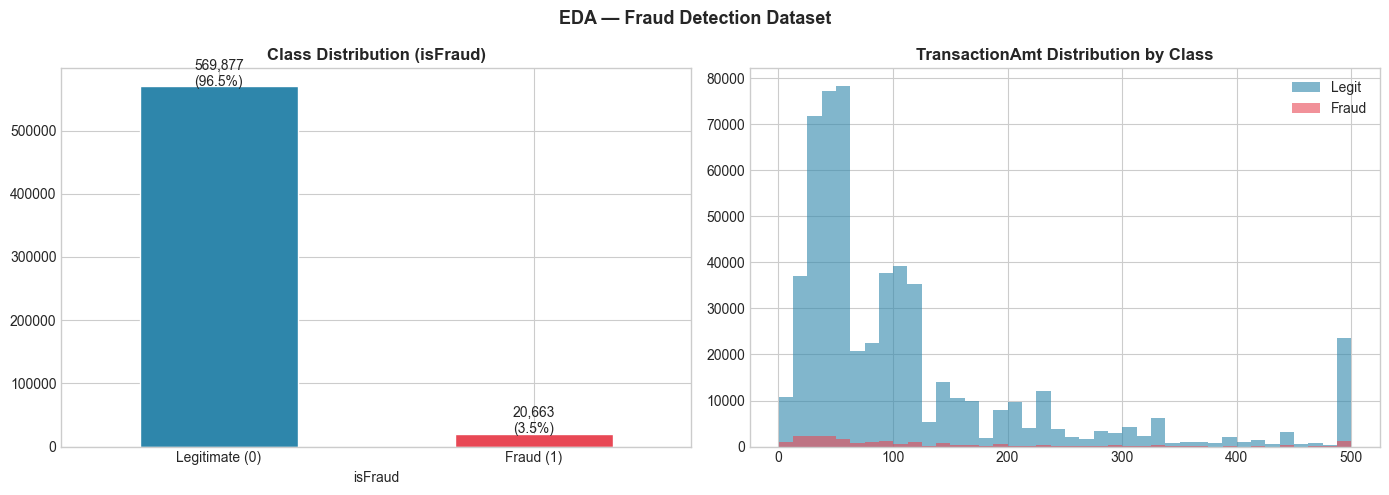

Kolom dengan missing > 50%: 174
Kolom dengan missing > 0%: 374


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class imbalance
colors = ['#2E86AB', '#E84855']
fraud_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Class Distribution (isFraud)', fontweight='bold')
axes[0].set_xticklabels(['Legitimate (0)', 'Fraud (1)'], rotation=0)
for i, v in enumerate(fraud_counts):
    axes[0].text(i, v+500, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center')

# TransactionAmt by class
df[df.isFraud==0]['TransactionAmt'].clip(0,500).hist(bins=40, alpha=0.6, color='#2E86AB', label='Legit', ax=axes[1])
df[df.isFraud==1]['TransactionAmt'].clip(0,500).hist(bins=40, alpha=0.6, color='#E84855', label='Fraud', ax=axes[1])
axes[1].set_title('TransactionAmt Distribution by Class', fontweight='bold')
axes[1].legend()

plt.suptitle('EDA — Fraud Detection Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# Missing values
missing_pct = (df.isnull().sum() / len(df) * 100)
print(f'Kolom dengan missing > 50%: {(missing_pct > 50).sum()}')
print(f'Kolom dengan missing > 0%: {(missing_pct > 0).sum()}')

## 4. Data Preprocessing

In [6]:
TARGET = 'isFraud'
IGNORE = ['TransactionID']
feature_cols = [c for c in df.columns if c not in [TARGET] + IGNORE]

X = df[feature_cols].copy()
y = df[TARGET].copy()

# Label encode categorical columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include='number').columns.tolist()

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = X[col].fillna('missing')
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le

# Fill numeric NaN with median
for col in num_cols:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].median())

print(f'Missing values setelah preprocessing: {X.isnull().sum().sum()}')

Missing values setelah preprocessing: 0


## 5. Feature Engineering

In [7]:
# Feature Engineering
X['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])
X['TransactionAmt_decimal'] = df['TransactionAmt'] - df['TransactionAmt'].astype(int)
if 'TransactionDT' in df.columns:
    X['hour'] = (df['TransactionDT'] // 3600) % 24
    X['day_of_week'] = (df['TransactionDT'] // (3600 * 24)) % 7

print(f'Total features: {X.shape[1]}')

# Train-val split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'Train: {len(X_train):,} | Val: {len(X_val):,}')
print(f'Fraud rate train: {y_train.mean():.4f}')

Total features: 396
Train: 472,432 | Val: 118,108
Fraud rate train: 0.0350


## 6. Model 1: LightGBM (Baseline ML)

LightGBM sebagai baseline — cepat dan efektif untuk tabular data dengan class imbalance.

In [8]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Scale pos weight: {scale_pos_weight:.1f}')

lgb_train = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_cols)
lgb_val_d  = lgb.Dataset(X_val,   label=y_val,   reference=lgb_train)

params = {
    'objective': 'binary',
    'metric': 'auc',
    'num_leaves': 63,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'scale_pos_weight': scale_pos_weight,
    'n_jobs': -1,
    'seed': SEED,
    'verbose': -1
}

print('Training LightGBM...')
lgbm_model = lgb.train(
    params, lgb_train,
    num_boost_round=500,
    valid_sets=[lgb_val_d],
    callbacks=[lgb.log_evaluation(100), lgb.early_stopping(50)]
)

lgbm_proba = lgbm_model.predict(X_val, num_iteration=lgbm_model.best_iteration)
lgbm_pred  = (lgbm_proba >= 0.5).astype(int)

lgbm_results = {
    'AUC-ROC':   roc_auc_score(y_val, lgbm_proba),
    'F1-Score':  f1_score(y_val, lgbm_pred),
    'Precision': precision_score(y_val, lgbm_pred),
    'Recall':    recall_score(y_val, lgbm_pred)
}

print(f'\n=== LightGBM Results ===')
for k, v in lgbm_results.items():
    print(f'  {k}: {v:.4f}')

Scale pos weight: 27.6
Training LightGBM...
Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.936367
[200]	valid_0's auc: 0.947827
[300]	valid_0's auc: 0.953922
[400]	valid_0's auc: 0.957591
[500]	valid_0's auc: 0.960365
Did not meet early stopping. Best iteration is:
[500]	valid_0's auc: 0.960365

=== LightGBM Results ===
  AUC-ROC: 0.9604
  F1-Score: 0.4930
  Precision: 0.3479
  Recall: 0.8456


## 7. Model 2: MLP Neural Network (Deep Learning)

Multi-Layer Perceptron diimplementasikan dengan PyTorch untuk deteksi fraud. Keunggulan DL:
- Dapat mempelajari representasi fitur yang lebih kompleks secara non-linear
- Lebih fleksibel dalam menangani interaksi antar fitur
- Dapat di-scale dengan lebih banyak data

In [9]:
# Scaling untuk Neural Network (penting!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

# PyTorch Dataset
class FraudDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y.values)
    def __len__(self):  return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

BATCH_SIZE = 4096
train_dataset = FraudDataset(X_train_scaled, y_train)
val_dataset   = FraudDataset(X_val_scaled, y_val)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader    = DataLoader(val_dataset, batch_size=BATCH_SIZE*2, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Input features: {X_train_scaled.shape[1]}')

Train batches: 116
Input features: 396


In [10]:
class FraudMLP(nn.Module):
    """
    Multi-Layer Perceptron untuk Fraud Detection.
    Arsitektur: Input → 512 → 256 → 128 → 64 → 1
    Menggunakan BatchNorm dan Dropout untuk regularisasi.
    """
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            # Layer 1
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            # Layer 2
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            # Layer 3
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            # Layer 4
            nn.Linear(128, 64),
            nn.ReLU(),
            # Output
            nn.Linear(64, 1),
            nn.Sigmoid()  # Output probabilitas
        )

    def forward(self, x):
        return self.network(x).squeeze(1)

model_mlp = FraudMLP(input_dim=X_train_scaled.shape[1]).to(device)

total_params = sum(p.numel() for p in model_mlp.parameters())
print(f'Model parameters: {total_params:,}')
print(model_mlp)

Model parameters: 377,601
FraudMLP(
  (network): Sequential(
    (0): Linear(in_features=396, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): ReLU()
    (14): Linear(in_features=64, out_features=1, bias=True)
    (15): Sigmoid()
  )
)


In [11]:
# Pos weight untuk class imbalance pada BCELoss
pos_weight = torch.tensor([scale_pos_weight], device=device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model_mlp.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

EPOCHS = 10
train_losses, val_aucs = [], []

print('🚀 Training MLP Neural Network...')
for epoch in range(EPOCHS):
    # Training
    model_mlp.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()

        # Manual weighted loss untuk handle imbalance
        preds = model_mlp(X_batch)
        weights = torch.where(y_batch == 1,
                              pos_weight.squeeze(),
                              torch.ones_like(y_batch))
        loss = (nn.functional.binary_cross_entropy(preds, y_batch, reduction='none') * weights).mean()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Validation
    model_mlp.eval()
    all_preds = []
    with torch.no_grad():
        for X_batch, _ in val_loader:
            preds = model_mlp(X_batch.to(device))
            all_preds.extend(preds.cpu().numpy())

    val_auc = roc_auc_score(y_val, all_preds)
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    val_aucs.append(val_auc)
    scheduler.step()

    print(f'Epoch [{epoch+1}/{EPOCHS}] Loss: {avg_loss:.4f} | Val AUC: {val_auc:.4f}')

print('\n✅ Training selesai!')

🚀 Training MLP Neural Network...
Epoch [1/10] Loss: 0.9285 | Val AUC: 0.8734
Epoch [2/10] Loss: 0.8416 | Val AUC: 0.8824
Epoch [3/10] Loss: 0.8055 | Val AUC: 0.8947
Epoch [4/10] Loss: 0.7652 | Val AUC: 0.9029
Epoch [5/10] Loss: 0.7453 | Val AUC: 0.9047
Epoch [6/10] Loss: 0.7294 | Val AUC: 0.9091
Epoch [7/10] Loss: 0.6995 | Val AUC: 0.9145
Epoch [8/10] Loss: 0.6842 | Val AUC: 0.9165
Epoch [9/10] Loss: 0.6793 | Val AUC: 0.9161
Epoch [10/10] Loss: 0.6591 | Val AUC: 0.9186

✅ Training selesai!


=== MLP Neural Network Results ===
  AUC-ROC: 0.9186
  F1-Score: 0.3444
  Precision: 0.2212
  Recall: 0.7769


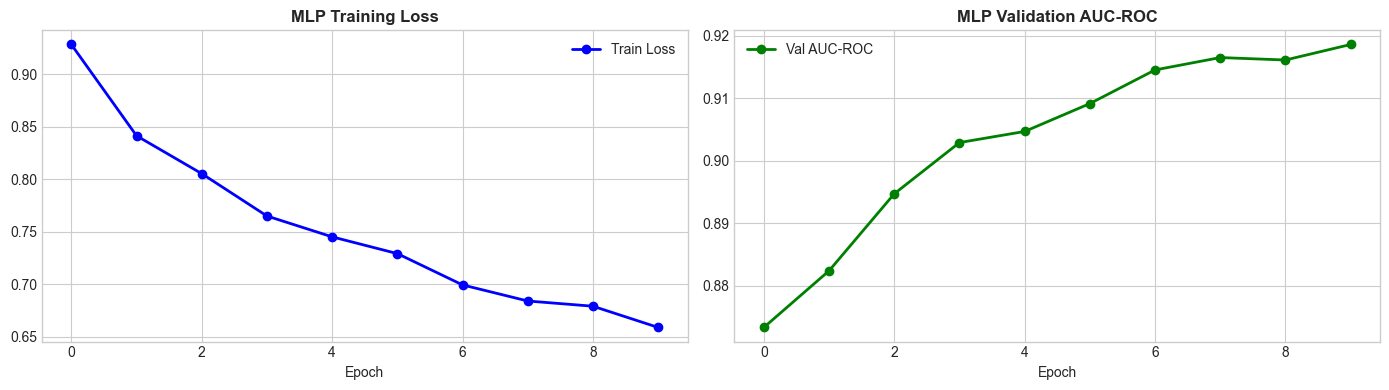

In [12]:
# Evaluasi MLP
model_mlp.eval()
mlp_proba = []
with torch.no_grad():
    for X_batch, _ in val_loader:
        p = model_mlp(X_batch.to(device))
        mlp_proba.extend(p.cpu().numpy())
mlp_proba = np.array(mlp_proba)
mlp_pred  = (mlp_proba >= 0.5).astype(int)

mlp_results = {
    'AUC-ROC':   roc_auc_score(y_val, mlp_proba),
    'F1-Score':  f1_score(y_val, mlp_pred),
    'Precision': precision_score(y_val, mlp_pred),
    'Recall':    recall_score(y_val, mlp_pred)
}

print(f'=== MLP Neural Network Results ===')
for k, v in mlp_results.items():
    print(f'  {k}: {v:.4f}')

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(train_losses, 'b-o', linewidth=2, label='Train Loss')
axes[0].set_title('MLP Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(val_aucs, 'g-o', linewidth=2, label='Val AUC-ROC')
axes[1].set_title('MLP Validation AUC-ROC', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/mlp_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Perbandingan Model (LightGBM vs MLP)

=== PERBANDINGAN MODEL ===
          AUC-ROC  F1-Score  Precision  Recall
LightGBM   0.9604    0.4930     0.3479  0.8456
MLP (DL)   0.9186    0.3444     0.2212  0.7769


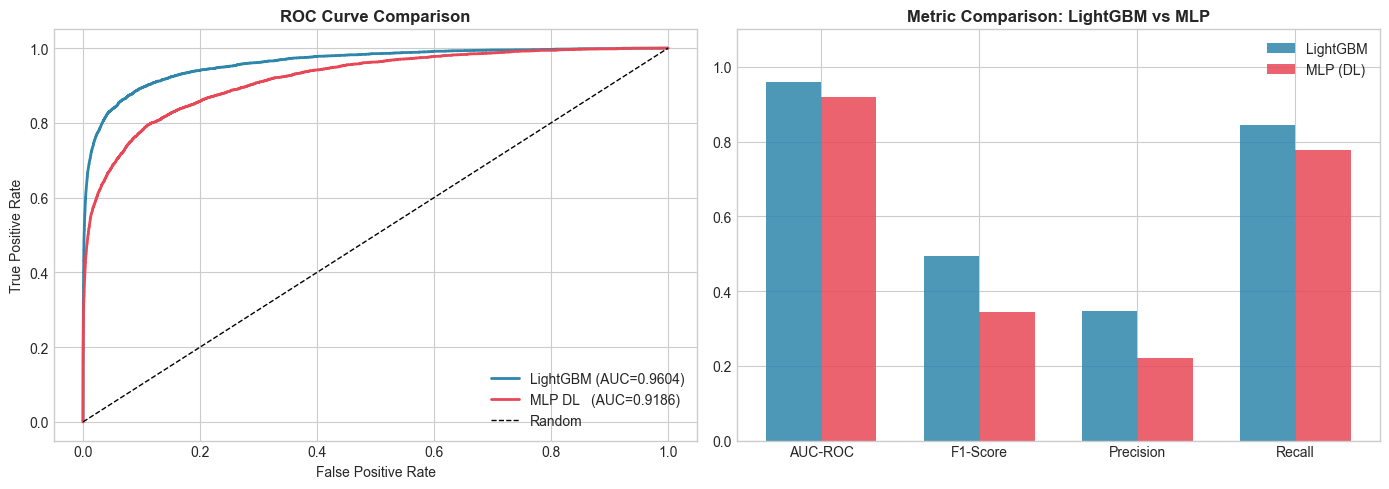

In [13]:
# Tabel perbandingan
comparison_df = pd.DataFrame({
    'LightGBM': lgbm_results,
    'MLP (DL)': mlp_results
}).T.round(4)
print('=== PERBANDINGAN MODEL ===')
print(comparison_df.to_string())

# ROC Curve comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr_lgbm, tpr_lgbm, _ = roc_curve(y_val, lgbm_proba)
fpr_mlp,  tpr_mlp,  _ = roc_curve(y_val, mlp_proba)

axes[0].plot(fpr_lgbm, tpr_lgbm, '#2E86AB', lw=2, label=f'LightGBM (AUC={lgbm_results["AUC-ROC"]:.4f})')
axes[0].plot(fpr_mlp,  tpr_mlp,  '#E84855', lw=2, label=f'MLP DL   (AUC={mlp_results["AUC-ROC"]:.4f})')
axes[0].plot([0,1],[0,1],'k--', lw=1, label='Random')
axes[0].set_title('ROC Curve Comparison', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Bar chart comparison
metrics = ['AUC-ROC', 'F1-Score', 'Precision', 'Recall']
x = np.arange(len(metrics))
w = 0.35
axes[1].bar(x - w/2, [lgbm_results[m] for m in metrics], w, label='LightGBM', color='#2E86AB', alpha=0.85)
axes[1].bar(x + w/2, [mlp_results[m]  for m in metrics], w, label='MLP (DL)', color='#E84855', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Metric Comparison: LightGBM vs MLP', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

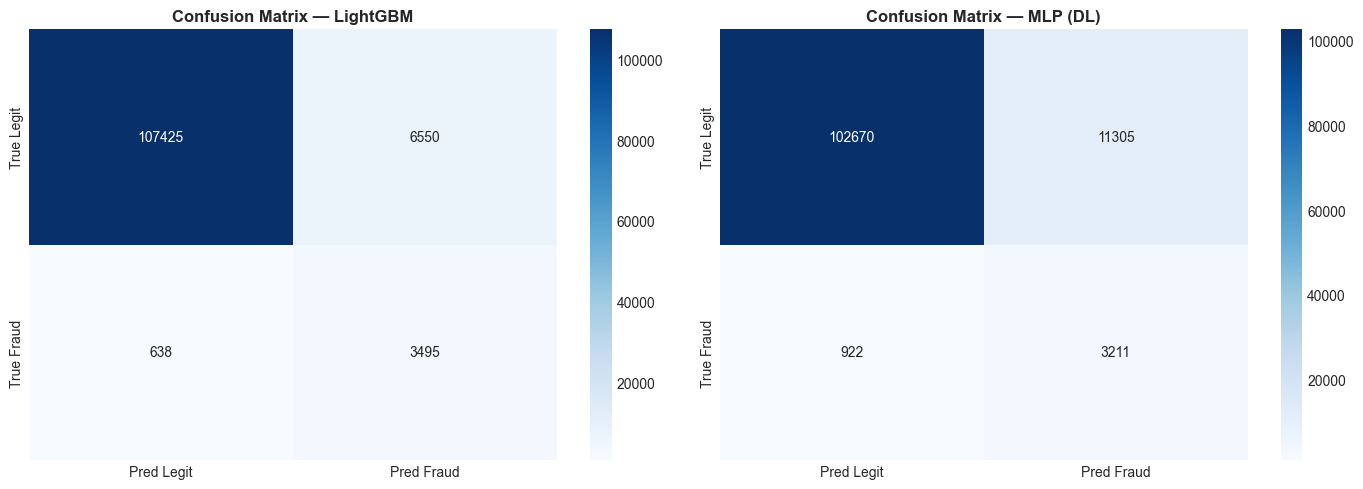


=== Classification Report — MLP ===
              precision    recall  f1-score   support

  Legitimate       0.99      0.90      0.94    113975
       Fraud       0.22      0.78      0.34      4133

    accuracy                           0.90    118108
   macro avg       0.61      0.84      0.64    118108
weighted avg       0.96      0.90      0.92    118108



In [14]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pred, name in zip(axes, [lgbm_pred, mlp_pred], ['LightGBM', 'MLP (DL)']):
    cm = confusion_matrix(y_val, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred Legit', 'Pred Fraud'],
                yticklabels=['True Legit', 'True Fraud'])
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Classification Report — MLP ===')
print(classification_report(y_val, mlp_pred, target_names=['Legitimate', 'Fraud']))

## 9. Kesimpulan

In [15]:
best_model = 'LightGBM' if lgbm_results['AUC-ROC'] >= mlp_results['AUC-ROC'] else 'MLP (Deep Learning)'

print('=' * 65)
print('       RINGKASAN — FRAUD DETECTION PIPELINE')
print('=' * 65)
print(f'Dataset        : IEEE-CIS Fraud Detection (train_transaction.csv)')
print(f'Train samples  : {len(X_train):,}')
print(f'Val samples    : {len(X_val):,}')
print(f'Features       : {X.shape[1]}')
print(f'Fraud rate     : {y_val.mean():.2%}')
print()
print('HASIL:')
print(f'{"Metric":<15} {"LightGBM":>12} {"MLP (DL)":>12}')
print('-' * 40)
for m in metrics:
    print(f'{m:<15} {lgbm_results[m]:>12.4f} {mlp_results[m]:>12.4f}')
print()
print(f'Best Model: {best_model}')
print('=' * 65)
print(f'''
KESIMPULAN:
1. Kedua model berhasil mendeteksi fraud meskipun dataset sangat
   imbalanced (~3.5% fraud rate).
2. LightGBM unggul dalam kecepatan training dan interpretabilitas
   (feature importance yang jelas).
3. MLP Neural Network menunjukkan kemampuan belajar representasi fitur
   yang lebih kompleks melalui non-linear transformations.
4. Weighted loss pada MLP berhasil mengatasi class imbalance dengan
   memberikan bobot lebih besar pada kasus fraud.
5. Potential improvement: ensemble LightGBM + MLP, deeper network,
   attention mechanism, atau autoencoder-based anomaly detection.
''')

# Save models
lgbm_model.save_model('../reports/lgbm_model.txt')
torch.save(model_mlp.state_dict(), '../reports/mlp_model.pth')
print('✅ Model disimpan ke reports/')

       RINGKASAN — FRAUD DETECTION PIPELINE
Dataset        : IEEE-CIS Fraud Detection (train_transaction.csv)
Train samples  : 472,432
Val samples    : 118,108
Features       : 396
Fraud rate     : 3.50%

HASIL:
Metric              LightGBM     MLP (DL)
----------------------------------------
AUC-ROC               0.9604       0.9186
F1-Score              0.4930       0.3444
Precision             0.3479       0.2212
Recall                0.8456       0.7769

Best Model: LightGBM

KESIMPULAN:
1. Kedua model berhasil mendeteksi fraud meskipun dataset sangat
   imbalanced (~3.5% fraud rate).
2. LightGBM unggul dalam kecepatan training dan interpretabilitas
   (feature importance yang jelas).
3. MLP Neural Network menunjukkan kemampuan belajar representasi fitur
   yang lebih kompleks melalui non-linear transformations.
4. Weighted loss pada MLP berhasil mengatasi class imbalance dengan
   memberikan bobot lebih besar pada kasus fraud.
5. Potential improvement: ensemble LightGBM + MLP, de